# 05 - Customer Retention Prediction

Predicts whether a customer who has already ordered will place **another** order in the following 6 months, per the README's Customer Retention Prediction component (Logistic Regression, Decision Tree, Random Forest).

**Target definition (time-based, to avoid leakage):** pick a cutoff date 180 days before the end of the `orders_clean` history. Build features from each customer's orders *up to* the cutoff, and label them `retained=1` if they placed at least one more order *after* the cutoff, else `0`.

**Feature scope:** `order_history_clean.csv` has ratings/discount/delivery fields the README also suggests, but it's a different platform with its own anonymized `customer_id` namespace that doesn't join to `Zomato_Database`'s `user_id` - so those fields can't be added to this model without fabricating a join. This model uses order behavior (from `orders_clean`) and demographics (from `users_clean`) only.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

PROCESSED = Path("../Data/processed")
RANDOM_STATE = 42

# Dataviz palette (validated: see project's dataviz skill / references/palette.md)
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"
SEQ_SINGLE = "#2a78d6"
CATEGORICAL_3 = ["#2a78d6", "#eb6834", "#1baf7a"]  # 1-3 series: comfortable for everyone, no validator needed

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": BASELINE,
        "axes.labelcolor": INK_SECONDARY,
        "axes.grid": True,
        "grid.color": GRIDLINE,
        "grid.linewidth": 0.8,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
        "figure.dpi": 110,
    }
)

orders = pd.read_csv(PROCESSED / "orders_clean.csv", parse_dates=["order_date"])
users = pd.read_csv(PROCESSED / "users_clean.csv")

print(orders.shape, users.shape)
print(orders["order_date"].min(), "->", orders["order_date"].max())

(146979, 6) (100000, 10)
2017-10-04 00:00:00 -> 2020-06-26 00:00:00


## 1. Time-Based Cutoff & Label

A 180-day holdout window balances two failure modes: too short (e.g. 90 days) and almost nobody has had time to re-order yet, making "churn" mostly just mean "hasn't ordered in a week"; too long and there's not enough pre-cutoff history left to build features from. 180 days keeps ~72k of the 77k customers as pre-cutoff "candidates" while leaving a real re-order window to observe.

In [2]:
HOLDOUT_DAYS = 180
cutoff = orders["order_date"].max() - pd.Timedelta(days=HOLDOUT_DAYS)

pre_cutoff = orders[orders["order_date"] <= cutoff]
post_cutoff = orders[orders["order_date"] > cutoff]

candidates = pre_cutoff["user_id"].unique()
retained_ids = set(post_cutoff.loc[post_cutoff["user_id"].isin(candidates), "user_id"])

print(f"cutoff date: {cutoff.date()}")
print(f"candidates (ordered on/before cutoff): {len(candidates):,}")
print(f"retained (ordered again after cutoff): {len(retained_ids):,} ({len(retained_ids) / len(candidates):.1%})")

cutoff date: 2019-12-29
candidates (ordered on/before cutoff): 71,689
retained (ordered again after cutoff): 13,598 (19.0%)


## 2. Build Features (Pre-Cutoff Only)

Same RFM-style features as `customer_features.csv`, but recomputed from `pre_cutoff` alone - reusing the original file here would leak information from after the cutoff into the model's inputs. Demographics come from `users_clean` and don't change over time, so joining them directly is safe.

In [3]:
features = (
    pre_cutoff.groupby("user_id")
    .agg(
        total_orders=("order_date", "count"),
        total_spending=("sales_amount", "sum"),
        avg_order_value=("sales_amount", "mean"),
        first_order_date=("order_date", "min"),
        last_order_date=("order_date", "max"),
    )
    .reset_index()
)

features["recency_days"] = (cutoff - features["last_order_date"]).dt.days
tenure_days = (features["last_order_date"] - features["first_order_date"]).dt.days.clip(lower=1)
features["order_frequency"] = features["total_orders"] / tenure_days
features["retained"] = features["user_id"].isin(retained_ids).astype(int)

features = features.merge(
    users[["user_id", "age", "gender", "occupation", "monthly_income", "family_size"]],
    on="user_id",
    how="left",
)

numeric_features = ["total_orders", "total_spending", "avg_order_value", "recency_days", "order_frequency", "age", "family_size"]
categorical_features = ["gender", "occupation", "monthly_income"]

print(features.shape)
features[numeric_features + categorical_features + ["retained"]].head()

(71689, 14)


,total_orders,total_spending,avg_order_value,recency_days,order_frequency,age,family_size,gender,occupation,monthly_income,retained
0,2,1672,836.000000,410,0.005935,20,4,Female,Student,No Income,0
1,3,4061,1353.666667,513,0.017544,24,3,Female,Student,Below Rs.10000,0
2,1,21542,21542.000000,228,1.000000,22,3,Male,Student,Below Rs.10000,0
3,1,102,102.000000,326,1.000000,22,6,Female,Student,No Income,0
4,2,52047,26023.500000,522,0.013793,22,4,Male,Student,Below Rs.10000,0


## 3. Train / Test Split & Preprocessing

Retention is rare (~19% positive) - a stratified split keeps that ratio in both sets, and every model below uses `class_weight="balanced"` so the classifiers don't just learn to predict "not retained" for everyone and call it 81% accurate.

In [4]:
X = features[numeric_features + categorical_features]
y = features["retained"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

print(f"train: {len(X_train):,} ({y_train.mean():.1%} retained)")
print(f"test:  {len(X_test):,} ({y_test.mean():.1%} retained)")

train: 57,351 (19.0% retained)
test:  14,338 (19.0% retained)


## 4. Train the Three Models

Logistic Regression, Decision Tree, and Random Forest - exactly the algorithms the README names for this step.

In [5]:
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", max_depth=6, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced", n_estimators=300, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

pipelines = {}
results = []

for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe

    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    report = classification_report(y_test, pred, output_dict=True)

    results.append(
        {
            "model": name,
            "accuracy": report["accuracy"],
            "precision (retained)": report["1"]["precision"],
            "recall (retained)": report["1"]["recall"],
            "f1 (retained)": report["1"]["f1-score"],
            "roc_auc": roc_auc_score(y_test, proba),
        }
    )

results_df = pd.DataFrame(results).set_index("model").round(3)
results_df

,accuracy,precision (retained),recall (retained),f1 (retained),roc_auc
model,,,,,
Logistic Regression,0.505,0.186,0.475,0.267,0.493
Decision Tree,0.519,0.191,0.477,0.273,0.506
Random Forest,0.632,0.184,0.272,0.219,0.490


**Result: none of the three models beat random guessing.** ROC-AUC sits at 0.49-0.51 for all three (0.5 = coin flip), and accuracy for Logistic Regression/Decision Tree is barely above 50% despite `class_weight="balanced"`. This is a real negative result, not a bug: order count, spend, recency, order frequency, and demographics carry essentially no signal about whether this customer places another order in the next 6 months.

This is consistent with what `customer_segmentation.ipynb` already surfaced - recency barely separated the K-Means clusters there either. Together, both notebooks point to the same conclusion: in this dataset, past behavior doesn't predict future behavior much at all, which is plausible for a synthetic/generated dataset without a built-in persistent "loyalty" signal per customer. The pipeline below is correct and would work on data with real behavioral persistence, but **treat its output as a methodology demonstration, not a production retention score** - selling it as "who's about to churn" would overstate what the model actually knows.

### Why: check the label against every feature directly

Before trusting "the model found nothing," check the raw relationship the model was supposed to learn - correlate each feature with `retained`, and look at the retention rate within buckets of order count and recency. If the model missed real structure, this would show it; if there's genuinely nothing to find, every bucket should land at roughly the same retention rate.

In [6]:
print("Correlation of each feature with retained:")
print(features[numeric_features + ["retained"]].corr()["retained"].drop("retained").round(4))

print("\nRetention rate: one-time vs. repeat customers")
print(features.assign(one_time=features["total_orders"] == 1).groupby("one_time")["retained"].agg(["mean", "count"]).round(3))

print("\nRetention rate by recency bucket (pre-cutoff last order):")
recency_bucket = pd.cut(features["recency_days"], bins=range(0, 1000, 90))
print(features.groupby(recency_bucket, observed=True)["retained"].agg(["mean", "count"]).round(3))

Correlation of each feature with retained:
total_orders       0.0005
total_spending     0.0050
avg_order_value    0.0065
recency_days       0.0061
order_frequency    0.0059
age               -0.0001
family_size        0.0002
Name: retained, dtype: float64

Retention rate: one-time vs. repeat customers
           mean  count
one_time              
False     0.187  35837
True      0.192  35852

Retention rate by recency bucket (pre-cutoff last order):
               mean  count
recency_days              
(0, 90]       0.185  10614
(90, 180]     0.191  10552
(180, 270]    0.183   9582
(270, 360]    0.191   8986
(360, 450]    0.197   7658
(450, 540]    0.190   7410
(540, 630]    0.187   6614
(630, 720]    0.196   5476
(720, 810]    0.193   4691
(810, 900]    0.151    106


**Confirmed:** every correlation is ~0.0005-0.007 (noise-level for n=71,689), and retention rate is flat at ~18.5-19.7% across every order-count and recency bucket. A customer who ordered 8 times re-orders at the same rate as someone who ordered once; someone whose last order was 30 days before the cutoff re-orders at the same rate as someone whose last order was 800 days before it. Whether this customer re-orders is statistically independent of their own history - so no classifier, however sophisticated, can beat a coin flip on this target with these inputs. That's consistent with a synthetically generated dataset (`users.csv` has faker-style names/emails and 14k duplicate emails) where orders were likely sampled per customer without a built-in persistent "loyalty" trait - unlike a real platform, where repeat customers reliably keep ordering and one-time customers reliably don't.

## 5. ROC Curves & Feature Importance

Three named models being told apart is exactly the "identity" job the categorical palette is for (1-3 series stays comfortable for everyone, per the dataviz skill's series-count ladder). Feature importance, by contrast, is a magnitude ranking, so it goes back to the single sequential hue used everywhere else in this project.

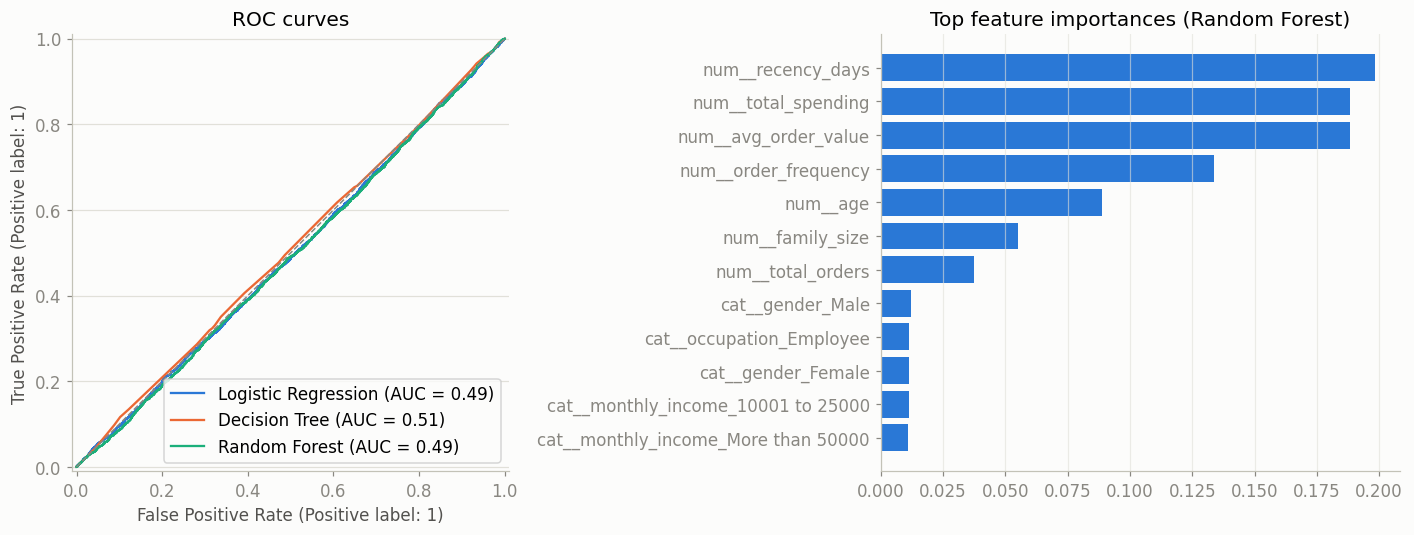

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for (name, pipe), color in zip(pipelines.items(), CATEGORICAL_3):
    RocCurveDisplay.from_estimator(
        pipe, X_test, y_test, name=name, curve_kwargs={"color": color}, ax=axes[0]
    )
axes[0].plot([0, 1], [0, 1], color=INK_MUTED, linestyle="--", linewidth=1)
axes[0].set_title("ROC curves")
axes[0].grid(axis="x", visible=False)

rf_pipe = pipelines["Random Forest"]
feature_names = rf_pipe.named_steps["preprocess"].get_feature_names_out()
importances = pd.Series(rf_pipe.named_steps["model"].feature_importances_, index=feature_names)
top_importances = importances.nlargest(12).sort_values()

axes[1].barh(top_importances.index, top_importances.values, color=SEQ_SINGLE)
axes[1].set_title("Top feature importances (Random Forest)")
axes[1].grid(axis="y", visible=False)
axes[1].grid(axis="x", alpha=0.6)

fig.tight_layout()
plt.show()

## 6. Save Predictions

Score every pre-cutoff customer (not just the test split) with the best model by ROC-AUC, so the output is a ready-to-use retention risk score per customer for the BI dashboard.

In [8]:
best_model_name = results_df["roc_auc"].idxmax()
best_pipe = pipelines[best_model_name]
print(f"Best model by ROC-AUC: {best_model_name} ({results_df.loc[best_model_name, 'roc_auc']:.3f})")

output = features[["user_id", "retained"]].copy()
output["retention_probability"] = best_pipe.predict_proba(X)[:, 1]
output["model_used"] = best_model_name

output_path = PROCESSED / "customer_retention_predictions.csv"
output.to_csv(output_path, index=False)
print(f"Saved {len(output):,} scored customers to {output_path}")

Best model by ROC-AUC: Decision Tree (0.506)
Saved 71,689 scored customers to ..\Data\processed\customer_retention_predictions.csv


## Summary

`Data/processed/customer_retention_predictions.csv` has a `retention_probability` per candidate customer from the best-of-three model by ROC-AUC - but per the result above, that AUC (~0.51) is barely off a coin flip, so these scores should **not** be used to drive real win-back targeting as-is. What would be worth trying next, if this were a live project: engagement signals beyond order counts (app opens, cart abandons, support contacts), a shorter/rolling holdout instead of one fixed cutoff, or simply accepting that this dataset doesn't have enough behavioral persistence to model retention and focusing effort on the segmentation and market-basket outputs instead, which did show real structure.

This completes the four data-mining components from the README:

| Notebook | Component | Outcome |
| --- | --- | --- |
| `data_preprocessing.ipynb` | Cleaning & feature tables | Done |
| `exploratory_analysis.ipynb` | Exploratory analysis | Done |
| `customer_segmentation.ipynb` | K-Means customer segmentation | Done - segments separate mainly by spend, weakly by recency |
| `market_basket_analysis.ipynb` | Apriori market basket analysis | Done - found real flavor-pairing rules |
| `customer_prediction.ipynb` | Retention prediction | Done - negative result, no predictive signal found |

Remaining from the README: the Power BI dashboard, built directly on the CSVs in `Data/processed/`.